2_markov_attribution_model includes:

- Data preparation: User sequences generated from user_id and events ordered chronologically.
- Markov model: Implementation to calculate each channel’s contribution to the conversion process.
- Results visualization: Bar chart showing the contributions of each channel.
- Lift analysis: Comparison between impacted and non-impacted users in terms of conversion rate.
- Results export: Attribution data is saved as a CSV file in markov_channel_attributions.csv.

In [31]:
# Importing Libraries
import pandas as pd
import numpy as np
from collections import Counter
import seaborn as sns
import matplotlib.pyplot as plt

# Setting Visualization Style
sns.set_theme(style="whitegrid")

In [32]:
# Markov Attribution
class MarkovAttribution:
    def __init__(self, transitions):
        self.transitions = transitions #User journeys (sequences of channels visited).
        self.transition_matrix = None #Stores probabilities of moving from one channel to another.
        self.removal_effects = None #Impact of removing a channel on the overall conversion rate.

    def build_transition_matrix(self):
        '''	
        Constructs a transition matrix based on user journeys.
        - Each user journey is augmented with a "START" state at the beginning and a "CONVERSION" state at the end.
        - Transitions between states are counted.
	    - Probabilities are calculated by dividing the count of a specific transition by the total transitions from a state.
	    - Probabilities are normalized to ensure they sum to 1.
        '''
        all_transitions = []
        for sequence in self.transitions:
            sequence = ["START"] + sequence + ["CONVERSION"]
            all_transitions.extend([(sequence[i], sequence[i + 1]) for i in range(len(sequence) - 1)])

        transition_counts = Counter(all_transitions)
        state_counts = Counter([t[0] for t in all_transitions])

        self.transition_matrix = {
            state: {
                next_state: transition_counts[(state, next_state)] / state_counts[state]
                for next_state in set(t[1] for t in all_transitions if t[0] == state)
            }
            for state in state_counts.keys()
        }

        for state, transitions in self.transition_matrix.items():
            total = sum(transitions.values())
            if total > 0:
                self.transition_matrix[state] = {
                    next_state: prob / total for next_state, prob in transitions.items()
                }

    def calculate_removal_effects(self):
        '''
        Estimates the impact of removing a channel on the overall conversion rate.
        - Temporarily removes a channel from the transition matrix.
	    - Simulates the new conversion rate without that channel.
        - The difference between the original and new conversion rates is stored as the channel’s removal effect.
        '''
        if self.transition_matrix is None:
            self.build_transition_matrix()

        self.removal_effects = {}
        original_conversion_rate = self.simulate_conversion_rate()

        for channel in [state for state in self.transition_matrix if state not in ["START", "CONVERSION"]]:
            modified_matrix = {
                state: {
                    next_state: prob
                    for next_state, prob in transitions.items()
                    if next_state != channel
                }
                for state, transitions in self.transition_matrix.items()
                if state != channel
            }

            # Normalize probabilities in the modified matrix
            for state, transitions in modified_matrix.items():
                total = sum(transitions.values())
                if total > 0:
                    modified_matrix[state] = {
                        next_state: prob / total for next_state, prob in transitions.items()
                    }

            modified_model = MarkovAttribution(self.transitions)
            modified_model.transition_matrix = modified_matrix
            modified_conversion_rate = modified_model.simulate_conversion_rate()

            self.removal_effects[channel] = original_conversion_rate - modified_conversion_rate

    def simulate_conversion_rate(self, num_simulations=50000):
        '''
        Simulates the conversion rate using the transition matrix.
        - Simulates 10,000 journeys starting from "START" and transitions through the matrix until reaching "CONVERSION" or exiting prematurely.
	    - The conversion rate is calculated as the proportion of journeys that reach "CONVERSION".
        '''
        if self.transition_matrix is None:
            self.build_transition_matrix()

        conversions = 0
        for _ in range(num_simulations):
            state = "START"
            while state != "CONVERSION":
                if state not in self.transition_matrix or not self.transition_matrix[state]:
                    break
                next_states = list(self.transition_matrix[state].keys())
                probabilities = list(self.transition_matrix[state].values())

                # Ensure probabilities sum to 1
                if not np.isclose(sum(probabilities), 1.0):
                    probabilities = [p / sum(probabilities) for p in probabilities]

                state = np.random.choice(next_states, p=probabilities)
            if state == "CONVERSION":
                conversions += 1

        return conversions / num_simulations

    def calculate_channel_contribution(self, threshold=0.01):
        '''
        Calculates each channel’s contribution to conversions based on removal effects.
        - Contributions are proportional to removal effects.
        - If no removal effects are detected, assigns equal contribution to all channels.
        '''
        if self.removal_effects is None:
            self.calculate_removal_effects()
        total_removal_effect = sum(self.removal_effects.values())

        # Handle division by zero if no removal effects are detected
        if total_removal_effect == 0:
            print("Warning: No removal effects detected. Assigning equal contribution to all channels.")
            num_channels = len(self.removal_effects)
            return {channel: 1 / num_channels for channel in self.removal_effects.keys()}

        # Apply a threshold to filter out insignificant channels
        filtered_removal_effects = {channel: effect for channel, effect in self.removal_effects.items() if effect > threshold}
        total_filtered_effect = sum(filtered_removal_effects.values())

        # If all channels have small effects, fall back to equal contribution
        if total_filtered_effect == 0:
            print("Warning: All channels have insignificant effects. Assigning equal contribution to all channels.")
            num_channels = len(self.removal_effects)
            return {channel: 1 / num_channels for channel in self.removal_effects.keys()}

        return {channel: effect / total_filtered_effect for channel, effect in filtered_removal_effects.items()}


In [33]:
# Load Processed Dataset
data_path = "processed_data.csv"
data = pd.read_csv(data_path)

# Preview Dataset
print("Preview of the Processed Dataset:")
print(data.head())

Preview of the Processed Dataset:
    user_id            timestamp         channel  event_type  conversion  \
0  user_716  2025-01-11 01:40:58    social_media       click           0   
1  user_775  2025-01-06 15:11:40    social_media       click           0   
2  user_968  2025-01-09 16:24:57  organic_search       click           0   
3  user_862  2025-01-23 08:11:47           email  conversion           1   
4  user_524  2025-01-09 00:43:19          direct       click           0   

   survey_score  
0           3.0  
1           3.0  
2           3.0  
3           5.0  
4           3.0  


In [34]:
# Prepare Data for Markov Model
print("\nPreparing Data for Markov Attribution Model...")
# Group user journeys into sequences by user_id and sort by timestamp
data.sort_values(by=["user_id", "timestamp"], inplace=True)
user_sequences = data.groupby("user_id")["channel"].apply(list).tolist()


Preparing Data for Markov Attribution Model...


In [35]:
# Display Sample User Sequences
print("Sample User Sequences:")
print(user_sequences[:5])

Sample User Sequences:
[['email', 'organic_search', 'display_ads', 'social_media', 'email'], ['social_media'], ['direct', 'social_media', 'display_ads', 'direct', 'email', 'direct', 'direct'], ['direct', 'direct', 'direct', 'organic_search'], ['email', 'display_ads', 'email', 'email', 'social_media']]


In [36]:
# Initialize Markov Attribution Model
print("\nInitializing Markov Attribution Model...")
markov_model = MarkovAttribution(transitions=user_sequences)

# Fit the Model and Calculate Attribution
print("\nFitting the Markov Model...")
channel_attributions = markov_model.calculate_channel_contribution()


Initializing Markov Attribution Model...

Fitting the Markov Model...


In [37]:
# Display Channel Attribution Results
attribution_df = pd.DataFrame(list(channel_attributions.items()), columns=["channel", "contribution"])
attribution_df.sort_values(by="contribution", ascending=False, inplace=True)
print("\nChannel Attribution Results:")
print(attribution_df)


Channel Attribution Results:
          channel  contribution
0           email           0.2
1  organic_search           0.2
2     display_ads           0.2
3    social_media           0.2
4          direct           0.2


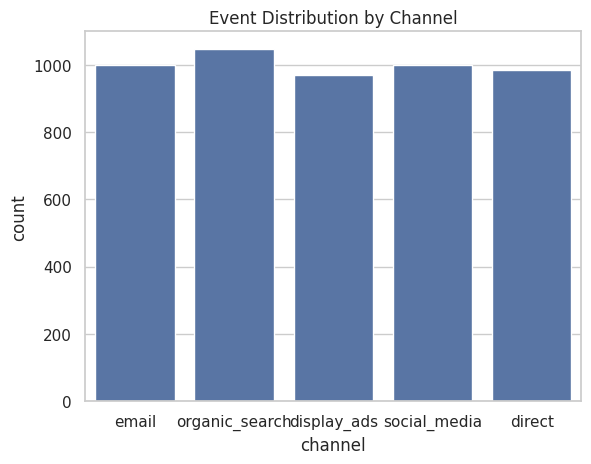

In [38]:
sns.countplot(x="channel", data=data)
plt.title("Event Distribution by Channel")
plt.show()

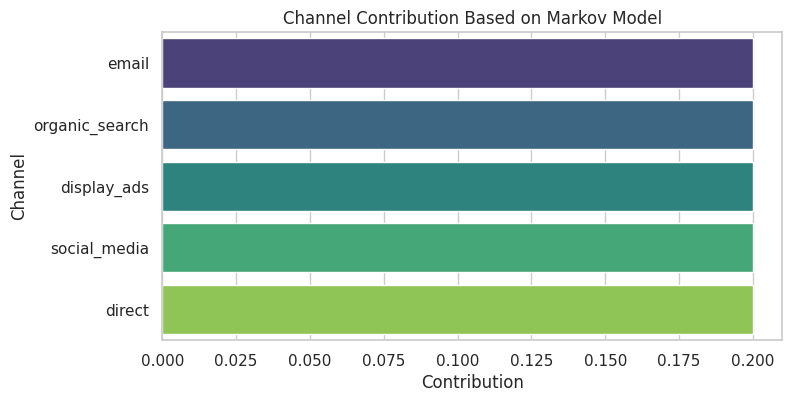

In [39]:
# Visualize Channel Contributions
plt.figure(figsize=(8, 4))
sns.barplot(x="contribution", y="channel", data=attribution_df, hue="channel", palette="viridis", legend=False)
plt.title("Channel Contribution Based on Markov Model")
plt.xlabel("Contribution")
plt.ylabel("Channel")
plt.show()

In [40]:
# Lift Analysis: Impacted vs. Non-Impacted Users
print("\nPerforming Lift Analysis...")
## Grouping Users by Impact
impacted_users = data[data["conversion"] == 1]["user_id"].unique()
non_impacted_users = data[~data["user_id"].isin(impacted_users)]["user_id"].unique()




Performing Lift Analysis...


In [41]:
# Calculating Lift
impacted_conversion_rate = data[data["user_id"].isin(impacted_users)]["conversion"].mean() * 100
non_impacted_conversion_rate = data[data["user_id"].isin(non_impacted_users)]["conversion"].mean() * 100
lift = impacted_conversion_rate - non_impacted_conversion_rate

print(f"Conversion Rate (Impacted Users): {impacted_conversion_rate:.2f}%")
print(f"Conversion Rate (Non-Impacted Users): {non_impacted_conversion_rate:.2f}%")
print(f"Lift in Conversion Rate: {lift:.2f}%")

Conversion Rate (Impacted Users): 21.80%
Conversion Rate (Non-Impacted Users): 0.00%
Lift in Conversion Rate: 21.80%


In [42]:
# Save Results
results_path = "markov_channel_attributions.csv"
attribution_df.to_csv(results_path, index=False)
print(f"\nMarkov Model Attribution results saved to {results_path}")


Markov Model Attribution results saved to markov_channel_attributions.csv
